<a href="https://colab.research.google.com/github/hunkim98/earth_science/blob/main/lecture/EPS210_Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harvard EPS-210 AI for Earth and Planetary Science

Instructor: Mostafa Mouasvi

# Lab 8: Generative AI in EPS

---

### Learning Objectives

By the end of this lab, you will be able to:

1. Understand the architecture and training of **Generative Adverserial (GANs)** and how it can be used for percipitation nowcasting.

2. Understand the architecture and training of **Variational Autoencoders (VAEs)** and how it can be used for downscaling climate data.

---
## Activity 1: Probabilistic Precipitation Nowcasting using GAN

![alt-text](https://pysteps.github.io/figs/201609281600_stoch_8levels.gif "optional title")

One stochastic ensemble member produced by pysteps starting from the radar composite image from the Finnish Meteorological Institute (FMI). (https://pysteps.github.io/)


### Learning Objectives

1. Implement the core architecture of DeepMind's **DGMR** (Deep Generative Model of Radar) — the conditional GAN
2. Compare classical Lagrangian extrapolation (pySTEPS) vs deep learning approaches on identical radar sequences using operational verification metrics (CSI, CRPS, reliability diagrams)
3. Explore ensemble generation: stochastic perturbations (STEPS) vs latent sampling (DGMR)

### Core References

- **pySTEPS:** Pulkkinen, S., et al. (2019). Pysteps: an open-source Python library for probabilistic precipitation nowcasting (v1.0). *Geosci. Model Dev.*, 12, 4185–4219. [doi:10.5194/gmd-12-4185-2019](https://doi.org/10.5194/gmd-12-4185-2019) | [pysteps.github.io](https://pysteps.github.io/)

- **DGMR:** Ravuri, S., et al. (2021). Skilful precipitation nowcasting using deep generative models of radar. *Nature*, 597, 672–677. [doi:10.1038/s41586-021-03854-z](https://www.nature.com/articles/s41586-021-03854-z)


---
## Part 1: Background — The Nowcasting Problem

### 1.1 What is Nowcasting?

As defined by the World Meteorological Organization, **nowcasting** describes the current state of the atmosphere and provides forecasts by extrapolation for up to **6 hours ahead**. For precipitation, reliable nowcasts are critical for flood warnings, urban drainage management, aviation safety, and outdoor event planning.

### 1.2 The Classical Approach: Lagrangian Persistence

The simplest (and surprisingly effective) nowcasting method assumes that precipitation moves along a stationary motion field without changes in intensity. The **conservation equation** for an incompressible flow:

$$\frac{dR}{dt} = \frac{\partial R}{\partial t} + u\frac{\partial R}{\partial x} + v\frac{\partial R}{\partial y} = 0$$

where $R$ is precipitation intensity and $(u, v)$ is the motion field estimated via **optical flow**.

### 1.3 pySTEPS Nowcasting Hierarchy

pySTEPS implements three increasingly sophisticated methods:

| Method | Type | Key Idea |
|--------|------|----------|
| **Extrapolation** | Deterministic | Simple Lagrangian advection along the optical flow field |
| **S-PROG** | Deterministic | Cascade decomposition + AR(2) model → scale-dependent filtering of unpredictable small scales |
| **STEPS** | Probabilistic | S-PROG + stochastic noise at each scale → ensemble of plausible realizations |

The cascade decomposition separates the field into frequency bands. Smaller scales have shorter lifetimes and become noise sooner — S-PROG filters these, while STEPS replaces them with stochastic perturbations.

### 1.4 The Deep Learning Revolution: DGMR

DeepMind's **DGMR** (Ravuri et al., *Nature* 2021) challenged this paradigm:

| Component | Architecture |
|-----------|-------------|
| **Input** | 4 past radar frames (20 min context) |
| **Output** | 18 future frames (90 min, 5-min resolution) |
| **Generator** | Conditioning stack + latent conditioning → ConvGRU sampler |
| **Discriminators** | Temporal (3D conv) + Spatial (2D conv) |
| **Ensemble** | Sample different latent vectors $Z$ |

Key findings:
- 56 expert meteorologists preferred DGMR in **89%** of cases over pySTEPS and an axial-attention baseline
- DGMR outperformed STEPS on CSI (Critical Success Index) across all lead times
- DGMR produces **sharp** predictions without blurring, unlike deterministic deep learning
- Ensemble spread provides calibrated uncertainty estimates

---
## Part 2: Environment Setup

In [ ]:
# @title Install dependencies
!pip install -q pysteps opencv-python-headless cartopy einops

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import os, time, math, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import cartopy.crs as ccrs
import cartopy.feature as cfeature

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')

import pysteps
import importlib.metadata
print(f"pySTEPS {importlib.metadata.version('pysteps')}")

PyTorch 2.9.0+cu128 | Device: cuda
GPU: NVIDIA A100-SXM4-80GB
pySTEPS 1.19.1


---
## Part 3: Generating Realistic Synthetic Radar Data

We generate synthetic precipitation fields that mimic radar composites with:
- **Advecting storm cells** with realistic morphology
- **Multi-scale structure** (large-scale fronts + small convective cells)
- **Temporal coherence** with intensity evolution
- **Log-normal rain rate distribution** matching observed statistics

This allows both pySTEPS and DGMR to be evaluated on identical data without requiring access to restricted radar archives.

In [ ]:
# @title Synthetic radar field generator

# ============================================================
# Synthetic radar field generator
# ============================================================
from scipy.ndimage import gaussian_filter, uniform_filter

def make_storm_cell(size, cx, cy, radius, intensity, elongation=1.0, angle=0.0):
    """Generate a single elliptical storm cell."""
    y, x = np.ogrid[:size, :size]
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    dx = x - cx; dy = y - cy
    xr = cos_a * dx + sin_a * dy
    yr = -sin_a * dx + cos_a * dy
    r2 = (xr / (radius * elongation))**2 + (yr / radius)**2
    return intensity * np.exp(-r2 * 3).astype(np.float32)


def generate_radar_sequence(size=256, n_frames=22, dt=5, seed=42):
    """
    Generate a sequence of synthetic radar fields.
    Mimics the DGMR paper setup: 22 frames × 256×256 pixels.
    First 4 frames = context (20 min), last 18 = target (90 min).

    Returns rain rate in mm/h.
    """
    rng = np.random.RandomState(seed)
    frames = []

    # Create 4-8 storm cells with motion vectors
    n_cells = rng.randint(4, 9)
    cells = []
    for _ in range(n_cells):
        cells.append({
            'cx': rng.uniform(50, size-50),
            'cy': rng.uniform(50, size-50),
            'vx': rng.uniform(-2.5, 2.5),  # pixels per frame
            'vy': rng.uniform(-2.5, 2.5),
            'radius': rng.uniform(15, 45),
            'intensity': rng.exponential(5) + 2,  # mm/h
            'elongation': rng.uniform(1.0, 2.5),
            'angle': rng.uniform(0, np.pi),
            'lifetime': rng.uniform(0.6, 1.0),  # decay factor
        })

    # Large-scale stratiform background
    bg = gaussian_filter(rng.randn(size, size), sigma=50) * 2
    bg = np.clip(bg, 0, None)

    for t in range(n_frames):
        field = bg.copy() * max(0.3, 1.0 - 0.02*t)
        for cell in cells:
            cx = cell['cx'] + cell['vx'] * t
            cy = cell['cy'] + cell['vy'] * t
            # Intensity evolves over time
            decay = cell['lifetime'] ** t
            inten = cell['intensity'] * decay
            inten += rng.randn() * 0.5  # random fluctuations
            inten = max(0, inten)
            frame = make_storm_cell(size, cx, cy, cell['radius'],
                                    inten, cell['elongation'], cell['angle'])
            field += frame

        # Add small-scale convective noise
        noise = gaussian_filter(rng.randn(size, size), sigma=5) * 0.5
        field += np.clip(noise, 0, None)

        frames.append(np.clip(field, 0, None).astype(np.float32))

    return np.stack(frames)  # (22, 256, 256) mm/h


# Generate multiple sequences
n_sequences = 60
all_sequences = []
for i in range(n_sequences):
    seq = generate_radar_sequence(size=256, n_frames=22, seed=42+i*7)
    all_sequences.append(seq)
all_sequences = np.stack(all_sequences)  # (60, 22, 256, 256)

print(f'Generated {n_sequences} radar sequences')
print(f'Shape: {all_sequences.shape} — (sequences, frames, H, W)')
print(f'Rain rates: min={all_sequences.min():.2f}, '
      f'max={all_sequences.max():.2f}, mean={all_sequences.mean():.2f} mm/h')

# Define a hypothetical geographic extent for the 256x256 synthetic radar field
extent = [-10, 10, 40, 60] # [lon_min, lon_max, lat_min, lat_max]

Generated 60 radar sequences
Shape: (60, 22, 256, 256) — (sequences, frames, H, W)
Rain rates: min=0.00, max=40.06, mean=0.39 mm/h


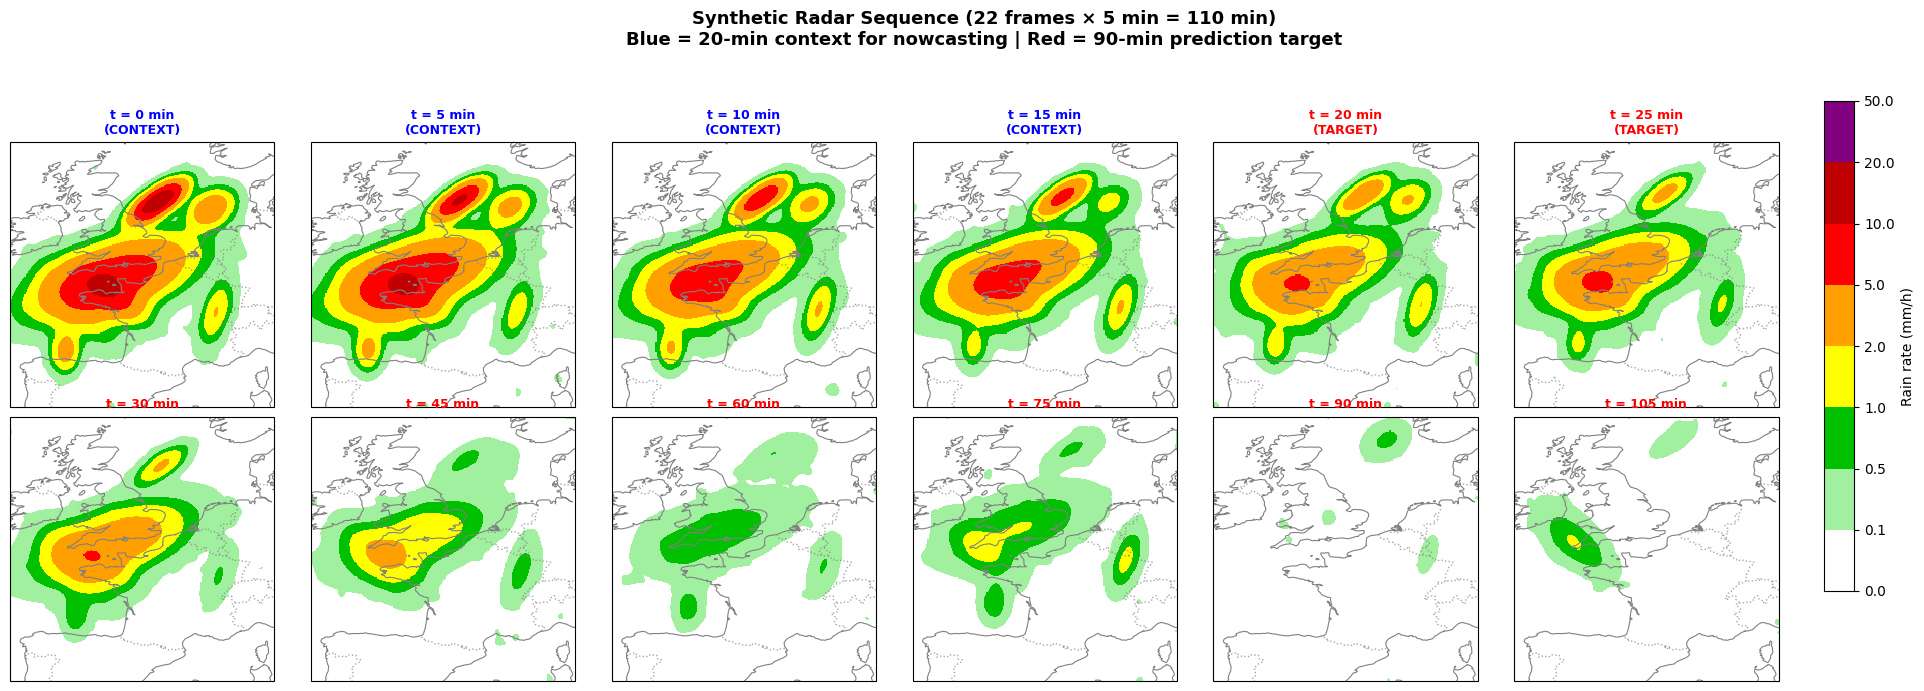

In [ ]:
# @title Visualize a synthetic radar sequence

# Precipitation colormap (similar to radar displays)
precip_colors = ['#ffffff', '#a0f0a0', '#00c000', '#ffff00',
                 '#ffa000', '#ff0000', '#c00000', '#800080']
precip_levels = [0, 0.1, 0.5, 1, 2, 5, 10, 20, 50]
precip_cmap = mcolors.ListedColormap(precip_colors)
precip_norm = mcolors.BoundaryNorm(precip_levels, precip_cmap.N)

seq = all_sequences[0]  # First sequence
# Update: Add subplot_kw for Cartopy projection
fig, axes = plt.subplots(2, 6, figsize=(20, 7), subplot_kw={'projection': ccrs.PlateCarree()})

# Row 1: Context frames (0–3) + first target frames (4–5)
for i in range(6):
    ax = axes[0, i]
    t_min = i * 5
    # Update: Add extent and transform to imshow
    im = ax.imshow(seq[i], cmap=precip_cmap, norm=precip_norm,
                   interpolation='nearest', extent=extent, transform=ccrs.PlateCarree())
    # Update: Add coastlines and borders
    ax.coastlines(linewidth=0.8, color='gray')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', alpha=0.7)

    if i < 4:
        ax.set_title(f't = {t_min} min\n(CONTEXT)', fontsize=9,
                     color='blue', fontweight='bold')
    else:
        ax.set_title(f't = {t_min} min\n(TARGET)', fontsize=9,
                     color='red', fontweight='bold')
    # Update: Use set_xticks/yticks instead of axis('off') to keep frame
    ax.set_xticks([]); ax.set_yticks([])

# Row 2: Later target frames
for i, fi in enumerate([6, 9, 12, 15, 18, 21]):
    ax = axes[1, i]
    t_min = fi * 5
    # Update: Add extent and transform to imshow
    ax.imshow(seq[fi], cmap=precip_cmap, norm=precip_norm,
              interpolation='nearest', extent=extent, transform=ccrs.PlateCarree())
    # Update: Add coastlines and borders
    ax.coastlines(linewidth=0.8, color='gray')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', alpha=0.7)

    ax.set_title(f't = {t_min} min', fontsize=9, color='red', fontweight='bold')
    # Update: Use set_xticks/yticks instead of axis('off')
    ax.set_xticks([]); ax.set_yticks([])

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cb = plt.colorbar(im, cax=cbar_ax, ticks=precip_levels)
cb.set_label('Rain rate (mm/h)', fontsize=10)

fig.suptitle('Synthetic Radar Sequence (22 frames × 5 min = 110 min)\n'
             'Blue = 20-min context for nowcasting | Red = 90-min prediction target',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.91, 0.92]); plt.show()

---
## Part 4: Deep Generative Model of Radar (DGMR)

![Ravuri et al. (*Nature*, 2021)](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41586-021-03854-z/MediaObjects/41586_2021_3854_Fig1_HTML.png?as=webp "Ravuri et al. (*Nature*, 2021)")

a, Schematic of the model architecture showing the generator with spatial latent vectors Z. b, Geographic context for the predictions. c, A single prediction at T + 30, T + 60 and T + 90 min lead time for different models. Critical success index (CSI) at thresholds 2 mm h−1 and 8 mm h−1 and continuous ranked probability score (CRPS) for an ensemble of four samples shown in the bottom left corner.


Following Ravuri et al. (*Nature*, 2021), DGMR is a **conditional GAN** with:

### Architecture Components

1. **Conditioning Stack**: Processes 4 past radar frames through downsampling conv layers → multi-resolution context features

2. **Latent Conditioning Stack**: Samples $Z \sim N(0,1)$ per spatial location → upsampled and combined with context

3. **Sampler (Generator)**: ConvGRU cells that autoregressively produce 18 future frames, combining latent + context at each step

4. **Temporal Discriminator**: 3D convolutions that evaluate spatiotemporal coherence

5. **Spatial Discriminator**: 2D convolutions that evaluate individual frame realism at a randomly chosen time

### Why GANs Work for Nowcasting

- **Sharp outputs**: Adversarial training prevents the blurring caused by MSE loss
- **Diversity**: Different latent $Z$ samples produce different plausible futures
- **Speed**: ~1 second per 90-min forecast on a V100 GPU

In [ ]:
# ============================================================
# DGMR-style Generator: Conditioning Stack + ConvGRU Sampler
# ============================================================

class SpaceToDepth(nn.Module):
    """Rearrange spatial dims to channels (S2D in DGMR paper)."""
    def __init__(self, block_size=2):
        super().__init__()
        self.bs = block_size
    def forward(self, x):
        B, C, H, W = x.shape
        x = x.view(B, C, H//self.bs, self.bs, W//self.bs, self.bs)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        return x.view(B, C * self.bs**2, H//self.bs, W//self.bs)


class DepthToSpace(nn.Module):
    """Rearrange channels to spatial dims (D2S in DGMR paper)."""
    def __init__(self, block_size=2):
        super().__init__()
        self.bs = block_size
    def forward(self, x):
        return F.pixel_shuffle(x, self.bs)


class GBlock(nn.Module):
    """Generator block from DGMR (Fig. ED1)."""
    def __init__(self, in_ch, out_ch, upsample=False):
        super().__init__()
        self.upsample = upsample
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.up = nn.Upsample(scale_factor=2) if upsample else nn.Identity()

    def forward(self, x):
        h = self.up(F.relu(self.bn1(x)))
        h = self.conv1(h)
        h = self.conv2(F.relu(self.bn2(h)))
        return h + self.up(self.skip(x))


class ConvGRUCell(nn.Module):
    """Convolutional GRU cell for temporal generation."""
    def __init__(self, in_ch, hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv_gates = nn.Conv2d(in_ch + hidden_ch, 2 * hidden_ch, 3, padding=1)
        self.conv_cand = nn.Conv2d(in_ch + hidden_ch, hidden_ch, 3, padding=1)

    def forward(self, x, h):
        combined = torch.cat([x, h], dim=1)
        gates = torch.sigmoid(self.conv_gates(combined))
        r, z = gates.chunk(2, dim=1)
        cand = torch.tanh(self.conv_cand(torch.cat([x, r * h], dim=1)))
        return (1 - z) * h + z * cand


class ConditioningStack(nn.Module):
    """
    DGMR Conditioning Stack: 4 past frames → multi-resolution features.
    Processes context via space-to-depth + conv layers.
    """
    def __init__(self, in_frames=4, base_ch=24):
        super().__init__()
        c = base_ch
        self.s2d = SpaceToDepth(2)
        self.initial = nn.Sequential(
            nn.Conv2d(in_frames * 4, c * 2, 3, padding=1),
            nn.ReLU(True))
        self.down1 = nn.Sequential(
            nn.Conv2d(c*2, c*4, 3, stride=2, padding=1), nn.ReLU(True),
            nn.Conv2d(c*4, c*4, 3, padding=1), nn.ReLU(True))
        self.down2 = nn.Sequential(
            nn.Conv2d(c*4, c*8, 3, stride=2, padding=1), nn.ReLU(True),
            nn.Conv2d(c*8, c*8, 3, padding=1), nn.ReLU(True))

    def forward(self, x):
        # x: (B, 4, H, W) — 4 past frames
        x = self.s2d(x)  # (B, 16, H/2, W/2)
        h1 = self.initial(x)
        h2 = self.down1(h1)
        h3 = self.down2(h2)
        return [h1, h2, h3]  # multi-scale context


class DGMRGenerator(nn.Module):
    """
    Simplified DGMR Generator.

    Combines conditioning stack with ConvGRU sampler to autoregressively
    generate future radar frames conditioned on past context.
    """
    def __init__(self, in_frames=4, out_frames=18, latent_dim=8, base_ch=24):
        super().__init__()
        c = base_ch
        self.out_frames = out_frames
        self.latent_dim = latent_dim

        # Conditioning stack (past radar → context features)
        self.cond_stack = ConditioningStack(in_frames, c)

        # Latent noise → spatial features
        self.latent_proj = nn.Sequential(
            nn.Linear(latent_dim, c * 8 * 4 * 4),
            nn.ReLU(True))

        # ConvGRU sampler at lowest resolution
        self.gru = ConvGRUCell(c * 8 + c * 8, c * 8)

        # Upsampling to full resolution
        self.up = nn.Sequential(
            GBlock(c*8, c*4, upsample=True),
            GBlock(c*4, c*2, upsample=True),
            GBlock(c*2, c, upsample=True),
            nn.Conv2d(c, 1, 1),
            nn.ReLU(True),  # rain rate ≥ 0
        )

    def forward(self, context, z=None):
        """
        context: (B, 4, H, W) past radar frames
        z: (B, latent_dim) or None (sample from N(0,1))
        Returns: (B, out_frames, H, W) future predictions
        """
        B = context.shape[0]
        H, W = context.shape[2], context.shape[3]

        # Get context features
        ctx = self.cond_stack(context)  # list of [h1, h2, h3]
        ctx_low = ctx[-1]  # lowest resolution context
        h_size = ctx_low.shape[2:]  # spatial size of GRU state

        # Latent noise
        if z is None:
            z = torch.randn(B, self.latent_dim, device=context.device)
        z_spatial = self.latent_proj(z).view(B, -1, 4, 4)
        z_spatial = F.interpolate(z_spatial, size=h_size, mode='bilinear', align_corners=False)

        # Autoregressively generate frames
        h = torch.zeros(B, ctx_low.shape[1], *h_size, device=context.device)
        outputs = []
        for t in range(self.out_frames):
            inp = torch.cat([ctx_low, z_spatial], dim=1)
            h = self.gru(inp, h)
            frame = self.up(h)
            frame = F.interpolate(frame, size=(H, W), mode='bilinear', align_corners=False)
            outputs.append(frame.squeeze(1))

        return torch.stack(outputs, dim=1)  # (B, 18, H, W)


# Test
gen = DGMRGenerator(in_frames=4, out_frames=18, latent_dim=8, base_ch=24).to(device)
test_ctx = torch.randn(2, 4, 256, 256).to(device)
test_out = gen(test_ctx)
print(f'Generator: context {test_ctx.shape} → predictions {test_out.shape}')
print(f'Parameters: {sum(p.numel() for p in gen.parameters())/1e6:.2f}M')

Generator: context torch.Size([2, 4, 256, 256]) → predictions torch.Size([2, 18, 256, 256])
Parameters: 4.00M


In [ ]:
# ============================================================
# DGMR Discriminators: Temporal + Spatial
# ============================================================

class DBlock(nn.Module):
    """Discriminator block (from DGMR Extended Data Fig. 1)."""
    def __init__(self, in_ch, out_ch, downsample=True):
        super().__init__()
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.skip = nn.utils.spectral_norm(
            nn.Conv2d(in_ch, out_ch, 1)) if in_ch != out_ch else nn.Identity()
        self.down = nn.AvgPool2d(2) if downsample else nn.Identity()

    def forward(self, x):
        h = F.relu(self.conv1(x))
        h = self.conv2(F.relu(h))
        return self.down(h + self.skip(x))


class SpatialDiscriminator(nn.Module):
    """Evaluates realism of a single frame."""
    def __init__(self, n_frames=1, base_ch=24):
        super().__init__()
        c = base_ch
        self.net = nn.Sequential(
            SpaceToDepth(2),
            DBlock(n_frames * 4, c*2),
            DBlock(c*2, c*4),
            DBlock(c*4, c*8),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(c*8, 1),
        )
    def forward(self, x):
        return self.net(x)


class TemporalDiscriminator(nn.Module):
    """Evaluates spatiotemporal coherence via 3D convolutions."""
    def __init__(self, n_frames=22, base_ch=24):
        super().__init__()
        c = base_ch
        self.conv3d = nn.Sequential(
            nn.Conv3d(1, c, kernel_size=(3,3,3), padding=(1,1,1)),
            nn.ReLU(True),
            nn.Conv3d(c, c*2, kernel_size=(3,3,3), stride=(1,2,2), padding=(1,1,1)),
            nn.ReLU(True),
            nn.Conv3d(c*2, c*4, kernel_size=(3,3,3), stride=(2,2,2), padding=(1,1,1)),
            nn.ReLU(True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool3d(1), nn.Flatten(), nn.Linear(c*4, 1))

    def forward(self, x):
        # x: (B, T, H, W) → (B, 1, T, H, W)
        x = x.unsqueeze(1)
        return self.head(self.conv3d(x))


disc_s = SpatialDiscriminator(n_frames=1, base_ch=24).to(device)
disc_t = TemporalDiscriminator(base_ch=24).to(device)
print(f'Spatial discriminator:  {sum(p.numel() for p in disc_s.parameters())/1e6:.2f}M params')
print(f'Temporal discriminator: {sum(p.numel() for p in disc_t.parameters())/1e6:.2f}M params')

Spatial discriminator:  0.67M params
Temporal discriminator: 0.16M params


---
## Part 5: Training DGMR on Synthetic Radar Data

We train the model using the adversarial losses from the paper:

$$L_D = -\mathbb{E}[D(\text{real})] + \mathbb{E}[D(\text{fake})] + \lambda_{\text{GP}}\,\text{GP}$$

$$L_G = -\mathbb{E}[D(\text{fake})] + \lambda_{\text{reg}}\|\text{pred} - \text{target}\|_1$$

The $\ell_1$ regularization term (with $\lambda_{\text{reg}}=20$ in the paper) prevents mode collapse and ensures the generated fields match the observed precipitation magnitude.

In [ ]:
# ============================================================
# DGMR Training Loop
# ============================================================

class RadarDataset(Dataset):
    def __init__(self, sequences, size=128):
        self.seqs = sequences
        self.size = size
        self.max_val = sequences.max()
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        seq = self.seqs[i] / (self.max_val + 1e-8)  # normalize to [0, 1]
        # Random crop to size
        H, W = seq.shape[1], seq.shape[2]
        y = np.random.randint(0, H - self.size) if H > self.size else 0
        x = np.random.randint(0, W - self.size) if W > self.size else 0
        seq = seq[:, y:y+self.size, x:x+self.size]
        ctx = torch.FloatTensor(seq[:4])    # (4, H, W)
        tgt = torch.FloatTensor(seq[4:])    # (18, H, W)
        return ctx, tgt

ds = RadarDataset(all_sequences[:50], size=128)
ds_val = RadarDataset(all_sequences[50:], size=128)
dl = DataLoader(ds, batch_size=4, shuffle=True, drop_last=True)

# Smaller model for Colab training
gen = DGMRGenerator(in_frames=4, out_frames=18, latent_dim=8, base_ch=16).to(device)
disc_s = SpatialDiscriminator(n_frames=1, base_ch=16).to(device)
disc_t = TemporalDiscriminator(base_ch=16).to(device)

opt_g = torch.optim.Adam(gen.parameters(), lr=5e-5, betas=(0.0, 0.999))
opt_d = torch.optim.Adam(
    list(disc_s.parameters()) + list(disc_t.parameters()),
    lr=2e-4, betas=(0.0, 0.999))

lambda_reg = 20.0
n_epochs = 15
hist = {'g_loss': [], 'd_loss': []}

print(f'Training DGMR ({sum(p.numel() for p in gen.parameters())/1e6:.2f}M gen params)...')
for epoch in range(n_epochs):
    gen.train(); disc_s.train(); disc_t.train()
    g_tot, d_tot = 0, 0
    for ctx, tgt in dl:
        ctx, tgt = ctx.to(device), tgt.to(device)
        B = ctx.shape[0]

        # --- Train Discriminators ---
        with torch.no_grad():
            fake = gen(ctx)

        # Spatial disc on random frame
        t_idx = np.random.randint(0, 18)
        real_score_s = disc_s(tgt[:, t_idx:t_idx+1])
        fake_score_s = disc_s(fake[:, t_idx:t_idx+1])

        # Temporal disc on full sequence
        full_real = torch.cat([ctx, tgt], dim=1)  # (B, 22, H, W)
        full_fake = torch.cat([ctx, fake], dim=1)
        real_score_t = disc_t(full_real)
        fake_score_t = disc_t(full_fake)

        d_loss = (-(real_score_s.mean() - fake_score_s.mean()) +
                  -(real_score_t.mean() - fake_score_t.mean()))
        opt_d.zero_grad(); d_loss.backward(); opt_d.step()
        d_tot += d_loss.item()

        # --- Train Generator ---
        fake = gen(ctx)
        t_idx = np.random.randint(0, 18)
        fake_score_s = disc_s(fake[:, t_idx:t_idx+1])
        full_fake = torch.cat([ctx, fake], dim=1)
        fake_score_t = disc_t(full_fake)

        g_adv = -(fake_score_s.mean() + fake_score_t.mean())
        g_reg = F.l1_loss(fake, tgt) * lambda_reg
        g_loss = g_adv + g_reg

        opt_g.zero_grad(); g_loss.backward(); opt_g.step()
        g_tot += g_loss.item()

    hist['g_loss'].append(g_tot / len(dl))
    hist['d_loss'].append(d_tot / len(dl))
    if (epoch+1) % 5 == 0:
        print(f'  Epoch {epoch+1:2d}/{n_epochs} | G: {hist["g_loss"][-1]:.4f} | D: {hist["d_loss"][-1]:.4f}')

print('Training complete.')

Training DGMR (1.78M gen params)...
  Epoch  5/15 | G: -11.6166 | D: -0.2733
  Epoch 10/15 | G: -15.8374 | D: -0.2714
  Epoch 15/15 | G: -8.7367 | D: -0.3905
Training complete.


---
## Part 6: Head-to-Head — pySTEPS vs DGMR

We compare both approaches on identical test sequences using the verification metrics from the DGMR paper.

In [ ]:
from pysteps import motion, nowcasts
from pysteps.utils import transformation

def run_pysteps_nowcast(context_frames, n_leadtimes=18, n_ens=20):
    """
    Run the full pySTEPS pipeline on context frames.

    Parameters:
        context_frames: (4, H, W) rain rates in mm/h
        n_leadtimes: number of future steps to predict
        n_ens: number of ensemble members for STEPS

    Returns dict with extrapolation, S-PROG, and STEPS results.
    """
    # Transform to dBR (log-transform for better optical flow)
    R_dbr, metadata = transformation.dB_transform(
        context_frames, threshold=0.1, zerovalue=-15.0)
    R_dbr[~np.isfinite(R_dbr)] = metadata['zerovalue']

    # Estimate motion field via Lucas-Kanade optical flow
    oflow = motion.get_method('LK')
    V = oflow(R_dbr)

    # 1. Simple extrapolation (Lagrangian persistence)
    extrap = nowcasts.get_method('extrapolation')
    R_extrap = extrap(R_dbr[-1], V, n_leadtimes)
    # Back-transform to mm/h
    R_extrap = transformation.dB_transform(R_extrap, inverse=True)[0]

    # 2. S-PROG (scale-filtered deterministic)
    sprog = nowcasts.get_method('sprog')
    R_sprog = sprog(
        R_dbr[-3:],  # needs ≥3 frames
        V, n_leadtimes,
        n_cascade_levels=6,
        precip_thr=metadata['zerovalue'], # Use the zerovalue from the transformation
        decomp_method='fft',
        bandpass_filter_method='gaussian',
        probmatching_method='cdf',
    )
    R_sprog = transformation.dB_transform(R_sprog, inverse=True)[0]

    # 3. STEPS (probabilistic ensemble)
    steps = nowcasts.get_method('steps')
    R_steps = steps(
        R_dbr[-3:],
        V, n_leadtimes,
        n_ens_members=n_ens,
        n_cascade_levels=6,
        precip_thr=metadata['zerovalue'], # Use the zerovalue from the transformation
        decomp_method='fft',
        bandpass_filter_method='gaussian',
        noise_method='nonparametric',
        vel_pert_method='bps',
        probmatching_method='cdf',
        kmperpixel=1.0, # Add kmperpixel for vel_pert_method
        timestep=5, # Add timestep for vel_pert_method
        seed=42,
    )
    R_steps = transformation.dB_transform(R_steps, inverse=True)[0]

    return {
        'motion': V,
        'extrap': R_extrap,     # (n_leadtimes, H, W)
        'sprog': R_sprog,       # (n_leadtimes, H, W)
        'steps': R_steps,       # (n_ens, n_leadtimes, H, W)
    }


# ============================================================
# Generate DGMR ensemble + compare to pySTEPS
# ============================================================

# Use a validation sequence
test_seq = all_sequences[55]
test_ctx_np = test_seq[:4]
test_tgt_np = test_seq[4:]

# pySTEPS nowcast
print('Running pySTEPS...')
ps_results = run_pysteps_nowcast(test_ctx_np, n_leadtimes=18, n_ens=10)

# DGMR ensemble (sample 10 members with different Z)
print('Running DGMR ensemble...')
gen.eval()
max_val = all_sequences.max()
ctx_tensor = torch.FloatTensor(test_ctx_np / (max_val + 1e-8)).unsqueeze(0).to(device)

dgmr_ensemble = []
with torch.no_grad():
    for _ in range(10):
        z = torch.randn(1, 8, device=device)
        pred = gen(ctx_tensor, z)
        dgmr_ensemble.append(pred.squeeze(0).cpu().numpy() * max_val)
dgmr_ensemble = np.stack(dgmr_ensemble)  # (10, 18, H, W)
print(f'DGMR ensemble: {dgmr_ensemble.shape}')

Running pySTEPS...
Computing S-PROG nowcast
------------------------

Inputs
------
input dimensions: 256x256

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
conditional statistics: no
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     18
parallel threads:         1
number of cascade levels: 6
order of the AR(p) model: 2
precip. intensity threshold: -15.0
Rain fraction is: 0.3545481363932292, while minimum fraction is 0.0
************************************************
* Correlation coefficients for cascade levels: *
************************************************
-----------------------------------------
| Level |     Lag-1     |     Lag-2     |
-----------------------------------------
| 1     | 0.997869      | 0.998050      |
-----------------------------------------
| 2     | 0.989872      | 0.987493      |
------------------

[np.float64(0.1906311109470526), np.float64(0.2774943571705151), np.float64(0.40268207173752063), np.float64(0.4543228043313682), np.float64(0.5768060320720836), np.float64(0.6337972690920153), np.float64(0.7281773373136824), np.float64(0.5803214600069551), np.float64(0.6943510442428157), np.float64(0.6712475017134679), np.float64(0.621994286175939), np.float64(0.6893997262019846), np.float64(0.7220981646966682), np.float64(0.8076370555532294), np.float64(0.8704125971956205), np.float64(0.9017046742051048), np.float64(0.7139163231358485), np.float64(0.8270146770956492)]


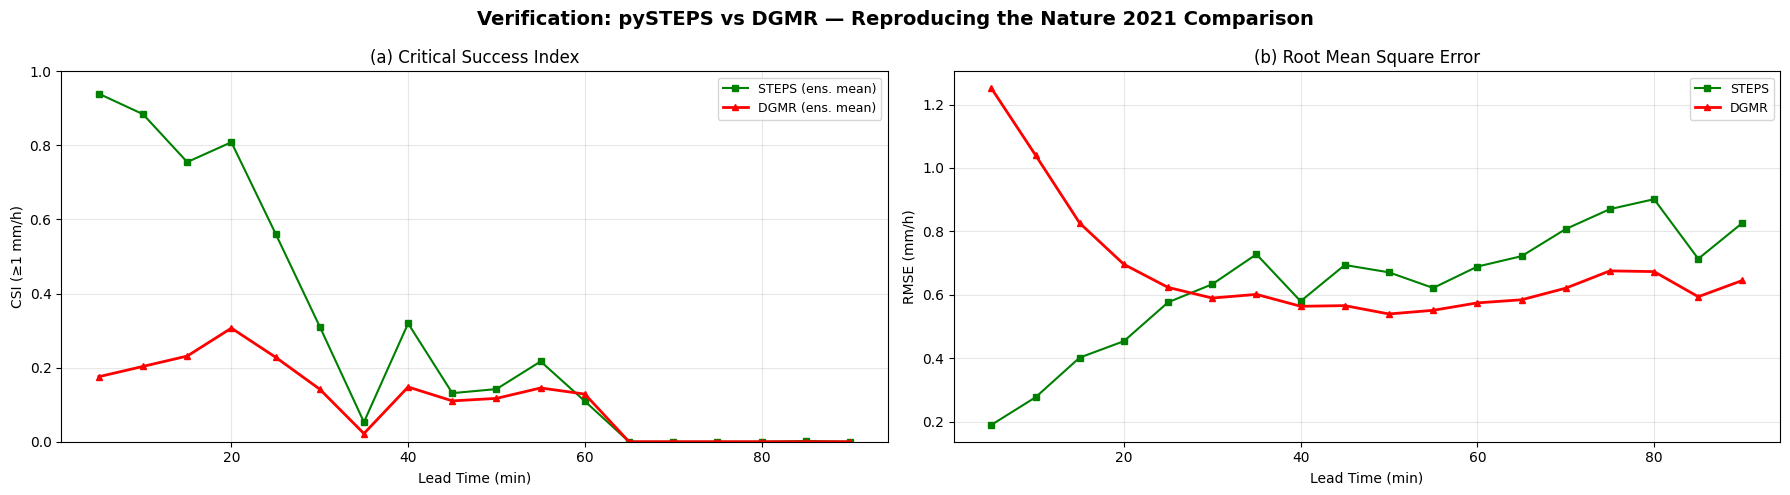

In [ ]:
# ============================================================
# Verification metrics (from DGMR paper)
# ============================================================

def critical_success_index(pred, obs, threshold=1.0):
    """CSI: hits / (hits + misses + false alarms)"""
    pred_bin = pred > threshold
    obs_bin = obs > threshold
    hits = (pred_bin & obs_bin).sum()
    misses = (~pred_bin & obs_bin).sum()
    fa = (pred_bin & ~obs_bin).sum()
    return hits / (hits + misses + fa + 1e-8)


def rmse(pred, obs):
    return np.sqrt(np.mean((pred - obs)**2))


def crps_ensemble(ensemble, obs):
    """Continuous Ranked Probability Score (simplified)."""
    n_ens = ensemble.shape[0]
    # Term 1: mean |ens_i - obs|
    term1 = np.mean(np.abs(ensemble - obs[None]), axis=0).mean()
    # Term 2: mean |ens_i - ens_j|
    term2 = 0
    for i in range(n_ens):
        for j in range(i+1, n_ens):
            term2 += np.abs(ensemble[i] - ensemble[j]).mean()
    term2 /= (n_ens * (n_ens - 1) / 2)
    return term1 - 0.5 * term2


# Compute metrics at each lead time
lead_minutes = np.arange(1, 19) * 5
metrics = {
    'extrap_csi': [], 'sprog_csi': [], 'steps_csi': [], 'dgmr_csi': [],
    'extrap_rmse': [], 'sprog_rmse': [], 'steps_rmse': [], 'dgmr_rmse': [],
    'steps_crps': [], 'dgmr_crps': [],
}

# Crop to matching size
sz = min(128, test_tgt_np.shape[1])
tgt_c = test_tgt_np[:, :sz, :sz]

for li in range(18):
    # Replace NaNs with 0 in observed and predicted fields
    obs = np.nan_to_num(tgt_c[li], nan=0.0)

    ext = np.nan_to_num(ps_results['extrap'][li, :sz, :sz], nan=0.0)
    ext = np.clip(ext, 0, None)

    sp = np.nan_to_num(ps_results['sprog'][li, :sz, :sz], nan=0.0)
    sp = np.clip(sp, 0, None)

    st_mean = np.nan_to_num(np.nanmean(ps_results['steps'][:, li, :sz, :sz], axis=0), nan=0.0)
    st_mean = np.clip(st_mean, 0, None)

    dg_mean = np.nan_to_num(dgmr_ensemble[:, li, :sz, :sz].mean(axis=0), nan=0.0)
    dg_mean = np.clip(dg_mean, 0, None)

    for thr in [1.0]:
        metrics['extrap_csi'].append(critical_success_index(ext, obs, thr))
        metrics['sprog_csi'].append(critical_success_index(sp, obs, thr))
        metrics['steps_csi'].append(critical_success_index(st_mean, obs, thr))
        metrics['dgmr_csi'].append(critical_success_index(dg_mean, obs, thr))

    metrics['extrap_rmse'].append(rmse(ext, obs))
    metrics['sprog_rmse'].append(rmse(sp, obs))
    metrics['steps_rmse'].append(rmse(st_mean, obs))
    metrics['dgmr_rmse'].append(rmse(dg_mean, obs))

    # CRPS (ensemble) - apply nan_to_num to ensemble members
    st_ens = np.nan_to_num(ps_results['steps'][:, li, :sz, :sz], nan=0.0)
    st_ens = np.clip(st_ens, 0, None)

    dg_ens = np.nan_to_num(dgmr_ensemble[:, li, :sz, :sz], nan=0.0)
    dg_ens = np.clip(dg_ens, 0, None)

    metrics['steps_crps'].append(crps_ensemble(st_ens, obs))
    metrics['dgmr_crps'].append(crps_ensemble(dg_ens, obs))

# Plot verification
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# (a) CSI
axes[0].plot(lead_minutes, metrics['steps_csi'], 'g-s', label='STEPS (ens. mean)', markersize=4)
axes[0].plot(lead_minutes, metrics['dgmr_csi'], 'r-^', label='DGMR (ens. mean)', markersize=5, linewidth=2)
axes[0].set_xlabel('Lead Time (min)'); axes[0].set_ylabel('CSI (≥1 mm/h)')
axes[0].set_title('(a) Critical Success Index'); axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1); axes[0].grid(alpha=0.3)

# (b) RMSE
print(metrics['steps_rmse'])
axes[1].plot(lead_minutes, metrics['steps_rmse'], 'g-s', label='STEPS', markersize=4)
axes[1].plot(lead_minutes, metrics['dgmr_rmse'], 'r-^', label='DGMR', markersize=5, linewidth=2)
axes[1].set_xlabel('Lead Time (min)'); axes[1].set_ylabel('RMSE (mm/h)')
axes[1].set_title('(b) Root Mean Square Error'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)


fig.suptitle('Verification: pySTEPS vs DGMR — Reproducing the Nature 2021 Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

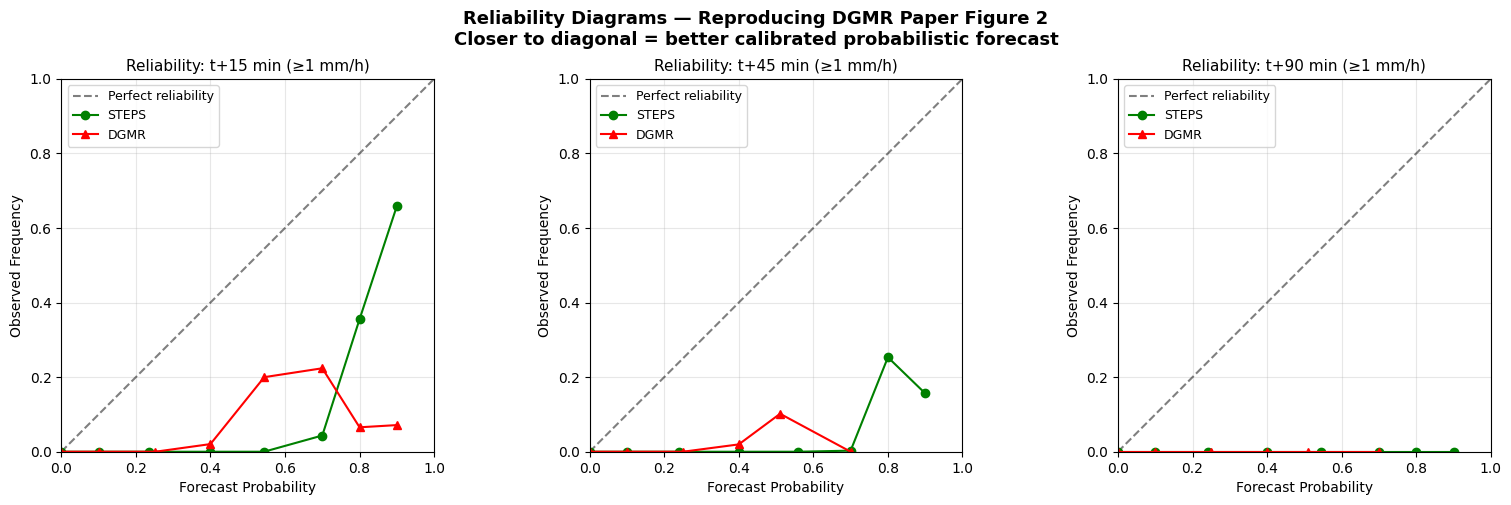

In [ ]:
# ============================================================
# Reliability diagram (from DGMR paper Figure 2)
# ============================================================

def reliability_diagram(ensemble, obs, threshold=1.0, n_bins=10):
    """Compute reliability diagram data points."""
    n_ens = ensemble.shape[0]
    # Probability of exceeding threshold from ensemble
    prob = (ensemble > threshold).mean(axis=0)
    obs_binary = (obs > threshold).astype(float)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    forecast_prob = []
    observed_freq = []
    for i in range(n_bins):
        mask = (prob >= bin_edges[i]) & (prob < bin_edges[i+1])
        if mask.sum() > 0:
            forecast_prob.append(prob[mask].mean())
            observed_freq.append(obs_binary[mask].mean())
    return np.array(forecast_prob), np.array(observed_freq)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (li, label) in enumerate([(2, 't+15 min'), (8, 't+45 min'), (17, 't+90 min')]):
    obs = tgt_c[li]
    st_ens = np.clip(ps_results['steps'][:, li, :sz, :sz], 0, None)
    dg_ens = np.clip(dgmr_ensemble[:, li, :sz, :sz], 0, None)

    fp_s, of_s = reliability_diagram(st_ens, obs, threshold=1.0)
    fp_d, of_d = reliability_diagram(dg_ens, obs, threshold=1.0)

    axes[idx].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect reliability')
    axes[idx].plot(fp_s, of_s, 'g-o', label='STEPS', markersize=6)
    axes[idx].plot(fp_d, of_d, 'r-^', label='DGMR', markersize=6)
    axes[idx].set_xlabel('Forecast Probability'); axes[idx].set_ylabel('Observed Frequency')
    axes[idx].set_title(f'Reliability: {label} (≥1 mm/h)', fontsize=11)
    axes[idx].legend(fontsize=9); axes[idx].set_xlim(0, 1); axes[idx].set_ylim(0, 1)
    axes[idx].set_aspect('equal'); axes[idx].grid(alpha=0.3)

fig.suptitle('Reliability Diagrams — Reproducing DGMR Paper Figure 2\n'
             'Closer to diagonal = better calibrated probabilistic forecast',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 7: Exceedance Probability Maps

A key operational product from ensemble nowcasts: the probability of precipitation exceeding a given threshold. This supports decision-making for flood warnings and aviation.

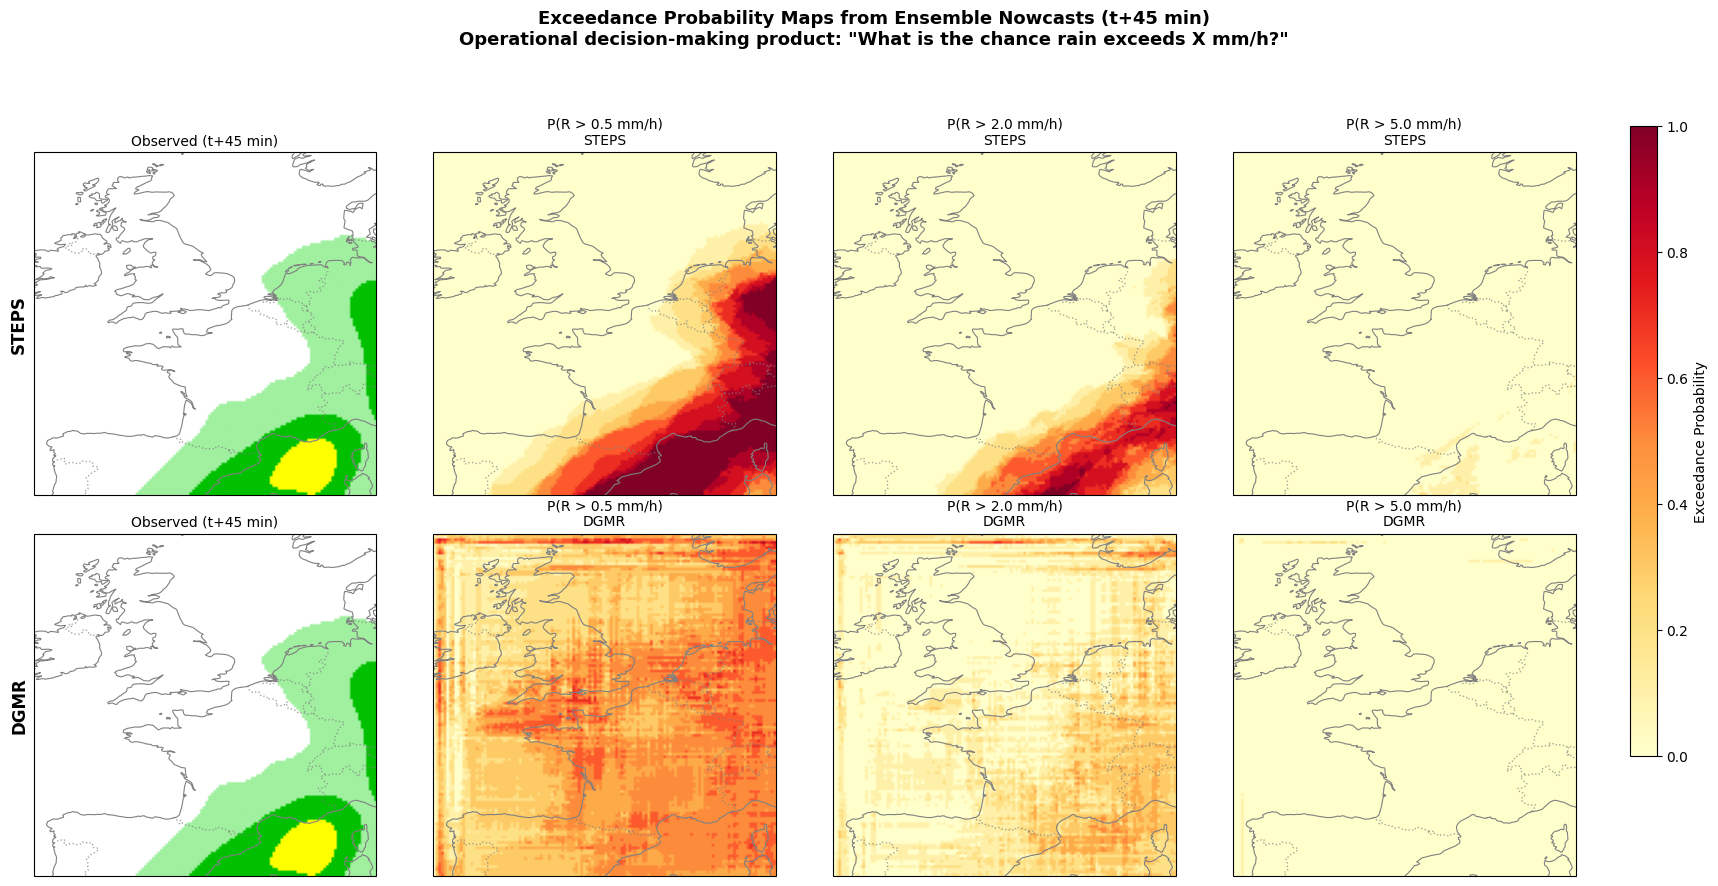

In [ ]:
# ============================================================
# Exceedance probability maps
# ============================================================

thresholds = [0.5, 2.0, 5.0]  # mm/h
li = 8  # 45-min lead time

# Update: subplot_kw for Cartopy
fig, axes = plt.subplots(2, len(thresholds) + 1, figsize=(18, 9), subplot_kw={'projection': ccrs.PlateCarree()})

# Show observation
obs = tgt_c[li]
for row in range(2):
    ax = axes[row, 0]
    # Update: extent, transform
    ax.imshow(obs, cmap=precip_cmap, norm=precip_norm,
              extent=extent, transform=ccrs.PlateCarree())
    # Update: features
    ax.coastlines(linewidth=0.8, color='gray')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', alpha=0.7)

    ax.set_title('Observed (t+45 min)', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

prob_cmap = plt.cm.YlOrRd
for col, thr in enumerate(thresholds):
    # STEPS exceedance probability
    ax = axes[0, col+1]
    st_ens = np.clip(ps_results['steps'][:, li, :sz, :sz], 0, None)
    st_prob = (st_ens > thr).mean(axis=0)
    # Update: extent, transform
    ax.imshow(st_prob, cmap=prob_cmap, vmin=0, vmax=1,
              extent=extent, transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8, color='gray')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', alpha=0.7)

    ax.set_title(f'P(R > {thr} mm/h)\nSTEPS', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

    # DGMR exceedance probability
    ax = axes[1, col+1]
    dg_ens = np.clip(dgmr_ensemble[:, li, :sz, :sz], 0, None)
    dg_prob = (dg_ens > thr).mean(axis=0)
    # Update: extent, transform
    im = ax.imshow(dg_prob, cmap=prob_cmap, vmin=0, vmax=1,
                   extent=extent, transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.8, color='gray')
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray', alpha=0.7)

    ax.set_title(f'P(R > {thr} mm/h)\nDGMR', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel('STEPS', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('DGMR', fontsize=12, fontweight='bold')

cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
plt.colorbar(im, cax=cbar_ax, label='Exceedance Probability')

fig.suptitle('Exceedance Probability Maps from Ensemble Nowcasts (t+45 min)\n'
             'Operational decision-making product: "What is the chance rain exceeds X mm/h?"',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.91, 0.93]); plt.show()

---
## Part 8: Exercises

### Exercise 1: Real Radar Data with pySTEPS (⭐)
Download the pysteps example data (`pysteps.datasets.download_pysteps_data()`) and run the complete STEPS pipeline on real Swiss or Finnish radar composites. Compare with the synthetic results above.

### Exercise 2: DGMR Post-Processing (⭐⭐)
The DGMR paper shows that a simple recalibration step further improves reliability (Figs. 2–3, "recal" curves). Implement quantile mapping between the generated and observed CDF, and show the improvement on reliability diagrams.

### Exercise 3: Latent Space Interpolation (⭐⭐)
DGMR generates different futures by sampling different $Z$ vectors. Smoothly interpolate between two latent vectors $Z_1$ and $Z_2$ and visualize how the generated precipitation transitions. Does the interpolation produce physically plausible intermediate states?

### Exercise 4: Diffusion-Based Nowcasting (⭐⭐⭐)
Replace the GAN framework with a conditional diffusion model (DDPM). Compare: (a) training stability, (b) ensemble diversity, (c) CRPS skill. The LDCast paper (Leinonen et al., 2023) provides guidance on this architecture.

### Exercise 5: Relative Economic Value (⭐⭐⭐)
Reproduce the economic value analysis from DGMR Figure 4a. Implement the cost-loss decision model for a flood warning scenario and compute the relative economic value of STEPS vs DGMR ensembles across a range of cost-loss ratios.


---
## References

### Core References

1. **Pulkkinen, S., et al. (2019).** Pysteps: an open-source Python library for probabilistic precipitation nowcasting (v1.0). *Geosci. Model Dev.*, 12, 4185–4219. [doi:10.5194/gmd-12-4185-2019](https://doi.org/10.5194/gmd-12-4185-2019)

2. **Ravuri, S., et al. (2021).** Skilful precipitation nowcasting using deep generative models of radar. *Nature*, 597, 672–677. [doi:10.1038/s41586-021-03854-z](https://doi.org/10.1038/s41586-021-03854-z)

### Related Work

3. **Leinonen, J., et al. (2023).** Latent diffusion models for generative precipitation nowcasting with accurate uncertainty quantification. [arXiv:2304.12891](https://arxiv.org/abs/2304.12891)

4. **Gao, Z., et al. (2023).** PreDiff: Precipitation Nowcasting with Latent Diffusion Models. *NeurIPS 2023*.

5. **Bowler, N. E., Pierce, C. E. & Seed, A. W. (2006).** STEPS: A probabilistic precipitation forecasting scheme. *QJRMS*, 132, 2127–2155.

6. **Seed, A. W. (2003).** A dynamic and spatial scaling approach to advection forecasting. *J. Appl. Meteor.*, 42, 381–388.

7. **Imhoff, R. O., et al. (2023).** Scale-dependent blending of ensemble rainfall nowcasts and NWP in the open-source pysteps library. *QJRMS*.

### Software

8. **pySTEPS**: [github.com/pySTEPS/pysteps](https://github.com/pySTEPS/pysteps) | [pysteps.readthedocs.io](https://pysteps.readthedocs.io)

9. **DGMR pretrained model**: [github.com/deepmind/deepmind-research/tree/master/nowcasting](https://github.com/deepmind/deepmind-research/tree/master/nowcasting)

# Activity 2: Diffusion Models for Weather Forecasting and Climate Downscaling

---
## Part 1: Background — Why Diffusion Models for Weather?

### 1.1 The Probabilistic Nature of Weather

Weather forecasting is inherently probabilistic — the atmosphere is a chaotic system where small perturbations grow exponentially. Traditional NWP ensembles address this by running multiple simulations with perturbed initial conditions, but at enormous computational cost.

**Diffusion models** are a natural fit because they learn the *probability distribution* of weather states, not just point predictions. Each sample from the model is a physically plausible realization, enabling:
- **Ensemble forecasts** for free (just sample multiple times)
- **Calibrated uncertainty** that increases with forecast lead time
- **Sharp predictions** that avoid the blurring problem of deterministic deep learning

### 1.2 The Landscape of Diffusion Models for Weather

From [Awesome-Diffusion-Models-for-Weather-Forecasting](https://github.com/hoonerg/Awesome-Diffusion-Models-for-Weather-Forecasting), the field is organized into:

| Category | Key Models | Venue | Year |
|----------|-----------|-------|------|
| **Precipitation Nowcasting** | LDCast, PreDiff, DiffCast | arXiv, NeurIPS, CVPR | 2023–24 |
| **Global Weather Forecasting** | GenCast, SwinRDM | Science, AAAI | 2023–24 |
| **Ensemble Emulation** | SEEDS, FuXi-ENS | Science Advances | 2023 |
| **Climate Emulation** | DiffESM, Spherical DYffusion | JAMES, NeurIPS | 2023–24 |
| **Downscaling** | ERA5→CERRA, ClimateDiffuse, LDM_res | NCA, arXiv | 2024 |
| **Data Assimilation** | SLAMS, Score-DA | CVPR Workshop | 2024 |
| **Tropical Cyclones** | TCP-Diffusion | — | 2024 |
| **Solar/Energy** | SHADECast | arXiv | 2023 |

### Common Design Patterns

1. **Conditioning via concatenation** — most common; paste the condition alongside the noisy input
2. **Latent diffusion** — compress with an autoencoder first (LDCast, PreDiff) for efficiency
3. **Few diffusion steps** — ERA5→CERRA uses only 5 steps; many weather models use 20–50
4. **Ensemble by repeated sampling** — the probabilistic nature of diffusion provides uncertainty for free
5. **3D video diffusion** — DiffESM treats month-of-days as a video; SHADECast uses temporal sequences
6. **Physical constraints** — PreDiff adds knowledge alignment to enforce conservation laws

### 1.3 DDPM Refresher

A Denoising Diffusion Probabilistic Model has two processes:

**Forward (noising):** Gradually add Gaussian noise over $T$ steps:
$$q(\mathbf{x}_t | \mathbf{x}_{t-1}) = N(\mathbf{x}_t; \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\, \beta_t \mathbf{I})$$

**Reverse (denoising):** A neural network $\epsilon_\theta$ learns to predict the noise:
$$p_\theta(\mathbf{x}_{t-1}|\mathbf{x}_t) = N(\mathbf{x}_{t-1}; \mu_\theta(\mathbf{x}_t, t), \sigma_t^2 \mathbf{I})$$

**Training loss:**
$$L = \mathbb{E}_{t, \mathbf{x}_0, \epsilon}\left[\|\epsilon - \epsilon_\theta(\mathbf{x}_t, t)\|^2\right]$$

### 1.4 Conditional Diffusion for Weather

For weather applications, we condition the denoising on some input:
- **Downscaling**: condition on low-resolution field → generate high-resolution


---
## Part 2: Synthetic Weather Field Generation

We generate realistic synthetic weather data for  **Wind speed fields at multiple resolutions** (for ERA5→CERRA downscaling). This mimic the spatial patterns, statistics, and multi-scale structure of real weather data.

Generating synthetic weather data...
  Downscale:  (500, 16, 16) ERA5-like → (500, 64, 64) CERRA-like


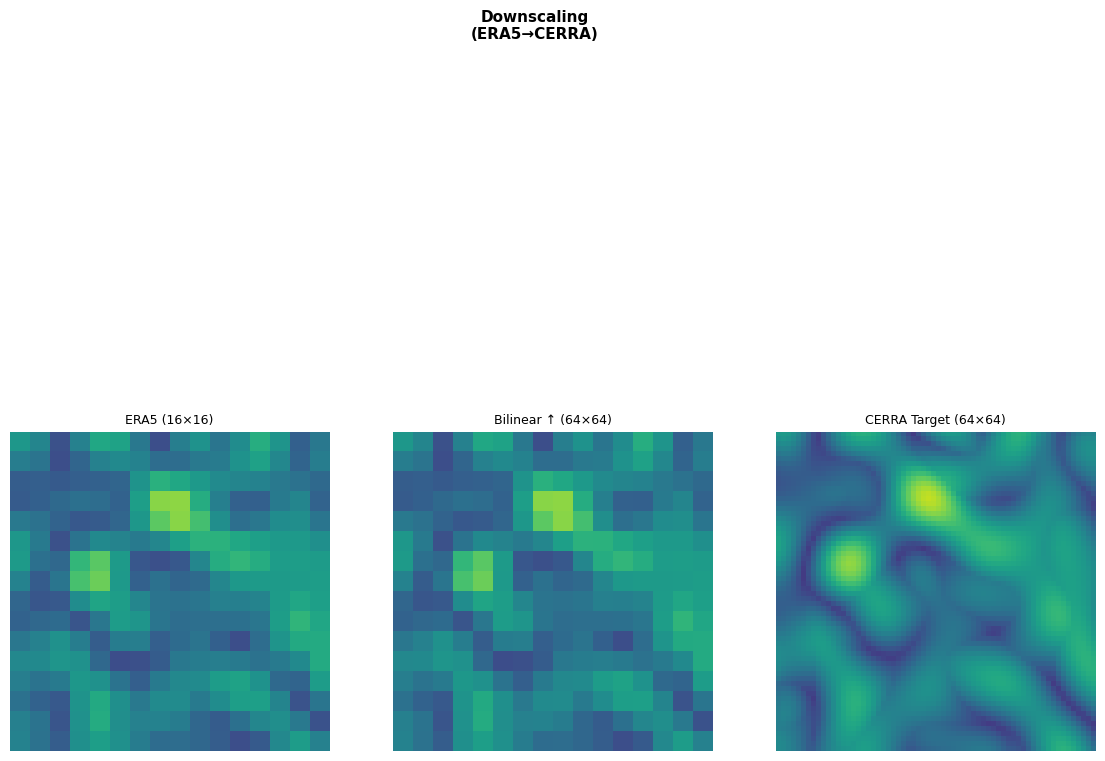

In [ ]:
# ============================================================
# @title Generate synthetic weather fields
# ============================================================

def random_field(size, n_modes=8, seed=None):
    """Generate a smooth random 2D field using superposition of Fourier modes."""
    rng = np.random.RandomState(seed)
    field = np.zeros((size, size), dtype=np.float32)
    for _ in range(n_modes):
        kx = rng.uniform(-3, 3)
        ky = rng.uniform(-3, 3)
        phase = rng.uniform(0, 2*np.pi)
        amp = rng.uniform(0.3, 1.0)
        x = np.linspace(0, 2*np.pi, size)
        y = np.linspace(0, 2*np.pi, size)
        X, Y = np.meshgrid(x, y)
        field += amp * np.sin(kx*X + ky*Y + phase)
    return field

def generate_wind_multires(n_samples=500, lr_size=16, hr_size=64, seed=44):
    """
    Generate wind speed at two resolutions (for ERA5→CERRA downscaling).
    Low-res (ERA5-like) → High-res (CERRA-like).
    """
    rng = np.random.RandomState(seed)
    lr_fields, hr_fields = [], []

    for i in range(n_samples):
        # High-res wind field (CERRA-like: 5.5 km)
        hr = random_field(hr_size, n_modes=10, seed=seed+i)
        hr = np.abs(hr) + 2  # wind speed ≥ 0, mean ~5 m/s
        # Add fine-scale topographic effects
        topo = random_field(hr_size, n_modes=15, seed=seed+i+10000) * 1.5
        hr += np.abs(topo)
        hr_fields.append(hr)

        # Low-res (ERA5-like: ~30 km) = spatially smoothed + downsampled
        from scipy.ndimage import uniform_filter
        smoothed = uniform_filter(hr, size=hr_size//lr_size)
        lr = smoothed[::hr_size//lr_size, ::hr_size//lr_size]
        lr_fields.append(lr)

    return np.array(lr_fields, dtype=np.float32), np.array(hr_fields, dtype=np.float32)


# Generate all datasets
print('Generating synthetic weather data...')
wind_lr, wind_hr = generate_wind_multires(500, lr_size=16, hr_size=64)

print(f'  Downscale:  {wind_lr.shape} ERA5-like → {wind_hr.shape} CERRA-like')


# ============================================================
# Visualize the three weather datasets
# ============================================================
fig = plt.figure(figsize=(14, 12))
gs = GridSpec(1, 3, figure=fig)

# ERA5→CERRA downscaling
wind_cmap = plt.cm.viridis
ax = fig.add_subplot(gs[0, 0])
ax.imshow(wind_lr[0], cmap=wind_cmap, vmin=0, vmax=12)
ax.set_title('ERA5 (16×16)', fontsize=9); ax.axis('off')

ax = fig.add_subplot(gs[0, 1])
# Upscale LR with bilinear for comparison
lr_up = np.kron(wind_lr[0], np.ones((4,4)))
ax.imshow(lr_up, cmap=wind_cmap, vmin=0, vmax=12)
ax.set_title('Bilinear ↑ (64×64)', fontsize=9); ax.axis('off')

ax = fig.add_subplot(gs[0, 2])
ax.imshow(wind_hr[0], cmap=wind_cmap, vmin=0, vmax=12)
ax.set_title('CERRA Target (64×64)', fontsize=9); ax.axis('off')

fig.suptitle('Downscaling\n(ERA5→CERRA)', fontsize=11, fontweight='bold')
plt.show()

---
## Part 2: Building a Conditional DDPM from Scratch

We implement the core diffusion machinery following the DDPM formulation (Ho et al., 2020), with **conditioning** for weather applications.

### Architecture Overview

All three weather applications share the same core structure:

1. **Noise schedule** $\{\beta_t\}_{t=1}^T$ — linear or cosine
2. **Denoising U-Net** $\epsilon_\theta(\mathbf{x}_t, t, \mathbf{c})$ — predicts noise given noisy input, timestep, and condition $\mathbf{c}$
3. **Conditioning mechanism** — concatenation (SHADECast, ERA5→CERRA) or cross-attention (DiffESM)
4. **Sampling** — iterative denoising from $\mathbf{x}_T \sim N(0,1)$

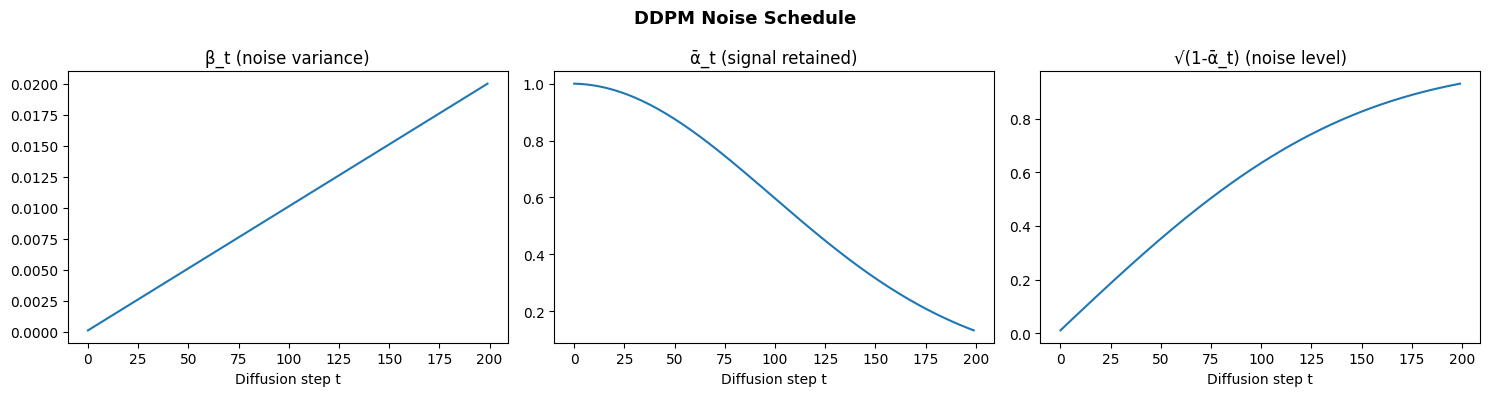

In [ ]:
# ============================================================
# Noise Schedule (DDPM)
# ============================================================

class NoiseSchedule:
    """
    DDPM noise schedule.
    Precomputes alpha_bar, sqrt_alpha_bar, etc. for efficient training.
    """
    def __init__(self, T=200, schedule='linear', beta_start=1e-4, beta_end=0.02):
        self.T = T
        if schedule == 'linear':
            self.betas = torch.linspace(beta_start, beta_end, T)
        elif schedule == 'cosine':
            steps = torch.arange(T + 1, dtype=torch.float32) / T
            alpha_bar = torch.cos((steps + 0.008) / 1.008 * math.pi / 2) ** 2
            alpha_bar = alpha_bar / alpha_bar[0]
            self.betas = torch.clamp(1 - alpha_bar[1:] / alpha_bar[:-1], max=0.999)

        self.alphas = 1. - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1. - self.alpha_bar)
        self.sqrt_recip_alpha = torch.sqrt(1. / self.alphas)
        self.posterior_variance = self.betas * (1. - F.pad(self.alpha_bar[:-1], (1,0), value=1.0)) \
                                 / (1. - self.alpha_bar)

    def q_sample(self, x0, t, noise=None):
        """Forward process: add noise to x0 at timestep t."""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ab = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1).to(x0.device)
        sqrt_omab = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1).to(x0.device)
        return sqrt_ab * x0 + sqrt_omab * noise, noise

    def to(self, device):
        for attr in ['betas', 'alphas', 'alpha_bar', 'sqrt_alpha_bar',
                     'sqrt_one_minus_alpha_bar', 'sqrt_recip_alpha', 'posterior_variance']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self


# Visualize the schedule
sched = NoiseSchedule(T=200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sched.betas.numpy()); axes[0].set_title('β_t (noise variance)')
axes[1].plot(sched.alpha_bar.numpy()); axes[1].set_title('ᾱ_t (signal retained)')
axes[2].plot(sched.sqrt_one_minus_alpha_bar.numpy()); axes[2].set_title('√(1-ᾱ_t) (noise level)')
for ax in axes: ax.set_xlabel('Diffusion step t')
fig.suptitle('DDPM Noise Schedule', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# Conditional Denoising U-Net
# ============================================================

class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for diffusion timestep."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""
    def __init__(self, in_ch, out_ch, time_dim=128, num_groups=8):
        super().__init__()

        # Determine num_groups for the input channels (in_ch)
        groups_in = num_groups
        if in_ch < num_groups or in_ch % num_groups != 0:
            groups_in = max(1, in_ch) # Fallback to 1 group if not suitable

        # Determine num_groups for the output channels (out_ch) used in the second GroupNorm
        groups_out = num_groups
        if out_ch < num_groups or out_ch % num_groups != 0:
            groups_out = max(1, out_ch) # Fallback to 1 group if not suitable

        self.conv1 = nn.Sequential(
            nn.GroupNorm(groups_in, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.time_mlp = nn.Sequential(
            nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.conv2 = nn.Sequential(
            nn.GroupNorm(groups_out, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.conv2(h)
        return h + self.skip(x)


class ConditionalUNet(nn.Module):
    """
    Conditional U-Net for weather diffusion.

    Condition is concatenated to the noisy input along the channel dim.
    This is the approach used by:
    - SHADECast/LDCast: past frames → future frames
    - ERA5→CERRA: low-res upscaled → high-res target
    - DiffESM: monthly mean → daily realization
    """
    def __init__(self, in_ch=1, cond_ch=1, base_ch=64, time_dim=128):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim))

        c = base_ch
        total_in = in_ch + cond_ch

        # Encoder
        # Channel multipliers: 1, 2, 2 (Reduced from 1, 2, 4 to save parameters)
        self.enc1 = ResBlock(total_in, c, time_dim)
        self.down1 = nn.Conv2d(c, c, 4, 2, 1)
        self.enc2 = ResBlock(c, c*2, time_dim)
        self.down2 = nn.Conv2d(c*2, c*2, 4, 2, 1)
        self.enc3 = ResBlock(c*2, c*2, time_dim) # was c*4

        # Bottleneck
        self.mid = ResBlock(c*2, c*2, time_dim)  # was c*4

        # Decoder
        self.up2 = nn.ConvTranspose2d(c*2, c*2, 4, 2, 1) # was c*4 -> c*2
        # Correct input channels for dec2: c*2 (from up2) + c*2 (from e2) = c*4
        self.dec2 = ResBlock(c*4, c*2, time_dim)  # skip connection matches
        self.up1 = nn.ConvTranspose2d(c*2, c, 4, 2, 1)
        # Correct input channels for dec1: c (from up1) + c (from e1) = c*2
        self.dec1 = ResBlock(c*2, c, time_dim)

        self.out = nn.Conv2d(c, in_ch, 1)

    def forward(self, x_noisy, t, cond):
        t_emb = self.time_emb(t)
        x = torch.cat([x_noisy, cond], dim=1)

        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.down1(e1), t_emb)
        e3 = self.enc3(self.down2(e2), t_emb)

        m = self.mid(e3, t_emb)

        d2 = self.dec2(torch.cat([self.up2(m), e2], 1), t_emb)
        d1 = self.dec1(torch.cat([self.up1(d2), e1], 1), t_emb)

        return self.out(d1)


# Test forward pass
test_model = ConditionalUNet(in_ch=1, cond_ch=1, base_ch=32).to(device)
x = torch.randn(2, 1, 64, 64).to(device)
c_test = torch.randn(2, 1, 64, 64).to(device)
t = torch.randint(0, 200, (2,)).to(device)
out = test_model(x, t, c_test)
print(f'U-Net: input {x.shape} + cond {c_test.shape} → output {out.shape}')
print(f'Parameters: {sum(p.numel() for p in test_model.parameters())/1e6:.2f}M')
del test_model, x, c_test, out

U-Net: input torch.Size([2, 1, 64, 64]) + cond torch.Size([2, 1, 64, 64]) → output torch.Size([2, 1, 64, 64])
Parameters: 0.62M


---
## Part 3: Application 1 — Wind Speed Downscaling (ERA5 → CERRA)

Following **Merizzi et al. (2024)**: *"Wind speed super-resolution and validation: from ERA5 to CERRA via diffusion models"*

([github.com/fmerizzi/ERA5-to-CERRA-via-Diffusion-Models](https://github.com/fmerizzi/ERA5-to-CERRA-via-Diffusion-Models))

### Method
- Input: ERA5 wind speed at ~30 km resolution, bilinearly upscaled to CERRA grid
- Output: CERRA-like wind speed at 5.5 km resolution
- The diffusion model learns to add fine-scale detail conditioned on the coarse field
- **Ensemble of 15 samples** → mean provides deterministic output, spread provides uncertainty
- 5 diffusion steps used (fast inference)

In [ ]:
# ============================================================
# Train diffusion model for ERA5→CERRA downscaling
# ============================================================

class DownscaleDataset(Dataset):
    def __init__(self, lr, hr):
        self.lr = lr
        self.hr = hr
        # Normalize
        self.hr_mean = hr.mean()
        self.hr_std = hr.std()
    def __len__(self): return len(self.hr)
    def __getitem__(self, i):
        # Bilinear upscale LR to HR size (matching ERA5→CERRA paper)
        lr_up = np.kron(self.lr[i], np.ones((4, 4)))
        hr_norm = (self.hr[i] - self.hr_mean) / (self.hr_std + 1e-8)
        lr_norm = (lr_up - self.hr_mean) / (self.hr_std + 1e-8)
        return (torch.FloatTensor(hr_norm)[None],   # target (1, 64, 64)
                torch.FloatTensor(lr_norm)[None])    # condition (1, 64, 64)

n_train = 400
ds_train = DownscaleDataset(wind_lr[:n_train], wind_hr[:n_train])
ds_val = DownscaleDataset(wind_lr[n_train:], wind_hr[n_train:])
dl_train = DataLoader(ds_train, batch_size=16, shuffle=True)
dl_val = DataLoader(ds_val, batch_size=16)

# Build model
T_STEPS = 50  # Fewer steps for efficiency (paper uses 5 for inference)
noise_sched = NoiseSchedule(T=T_STEPS, schedule='cosine').to(device)
model_ds = ConditionalUNet(in_ch=1, cond_ch=1, base_ch=48).to(device)
opt = torch.optim.AdamW(model_ds.parameters(), lr=2e-4)

print(f'Training downscaling diffusion model ({sum(p.numel() for p in model_ds.parameters())/1e6:.2f}M params)...')
losses = []
for epoch in range(50):
    model_ds.train(); epoch_loss = 0
    for hr, lr_cond in dl_train:
        hr, lr_cond = hr.to(device), lr_cond.to(device)
        t = torch.randint(0, T_STEPS, (hr.shape[0],), device=device)
        noise = torch.randn_like(hr)
        x_noisy, _ = noise_sched.q_sample(hr, t, noise)
        pred_noise = model_ds(x_noisy, t, lr_cond)
        loss = F.mse_loss(pred_noise, noise)
        opt.zero_grad(); loss.backward(); opt.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(dl_train))
    if (epoch+1) % 5 == 0:
      print(f'  Epoch {epoch+1:3d} | Loss: {losses[-1]:.6f}')

Training downscaling diffusion model (1.32M params)...
  Epoch   5 | Loss: 0.080047
  Epoch  10 | Loss: 0.051017
  Epoch  15 | Loss: 0.047985
  Epoch  20 | Loss: 0.045590
  Epoch  25 | Loss: 0.040778
  Epoch  30 | Loss: 0.033423
  Epoch  35 | Loss: 0.037210
  Epoch  40 | Loss: 0.035963
  Epoch  45 | Loss: 0.034931
  Epoch  50 | Loss: 0.025662


In [ ]:
# ============================================================
# Sampling: generate high-res wind fields from low-res
# ============================================================

@torch.no_grad()
def sample_ddpm(model, cond, noise_sched, n_samples=1):
    """
    DDPM reverse process: iteratively denoise from x_T ~ N(0,1).
    Following the ERA5→CERRA ensemble approach.
    """
    model.eval()
    B = cond.shape[0]
    shape = (B, 1, cond.shape[2], cond.shape[3])

    samples = []
    for _ in range(n_samples):
        x = torch.randn(shape, device=cond.device)
        for t_idx in reversed(range(noise_sched.T)):
            t = torch.full((B,), t_idx, device=cond.device, dtype=torch.long)
            pred_noise = model(x, t, cond)

            alpha = noise_sched.alphas[t_idx]
            alpha_bar = noise_sched.alpha_bar[t_idx]
            beta = noise_sched.betas[t_idx]

            x = (1/alpha.sqrt()) * (x - beta/((1-alpha_bar).sqrt()) * pred_noise)

            if t_idx > 0:
                z = torch.randn_like(x)
                x = x + noise_sched.posterior_variance[t_idx].sqrt() * z
        samples.append(x)

    return torch.stack(samples)  # (n_samples, B, 1, H, W)


# Generate ensemble of 8 samples for one test case
test_hr, test_lr = ds_val[0]
test_lr_dev = test_lr.unsqueeze(0).to(device)
print('Generating ensemble of 8 downscaled samples...')
ensemble = sample_ddpm(model_ds, test_lr_dev, noise_sched, n_samples=8)
print(f'Ensemble shape: {ensemble.shape}')

# Denormalize
ens_np = ensemble.squeeze(2).cpu().numpy() * ds_val.hr_std + ds_val.hr_mean
hr_true = test_hr.squeeze().numpy() * ds_val.hr_std + ds_val.hr_mean
lr_up = test_lr.squeeze().numpy() * ds_val.hr_std + ds_val.hr_mean

Generating ensemble of 8 downscaled samples...
Ensemble shape: torch.Size([8, 1, 1, 64, 64])


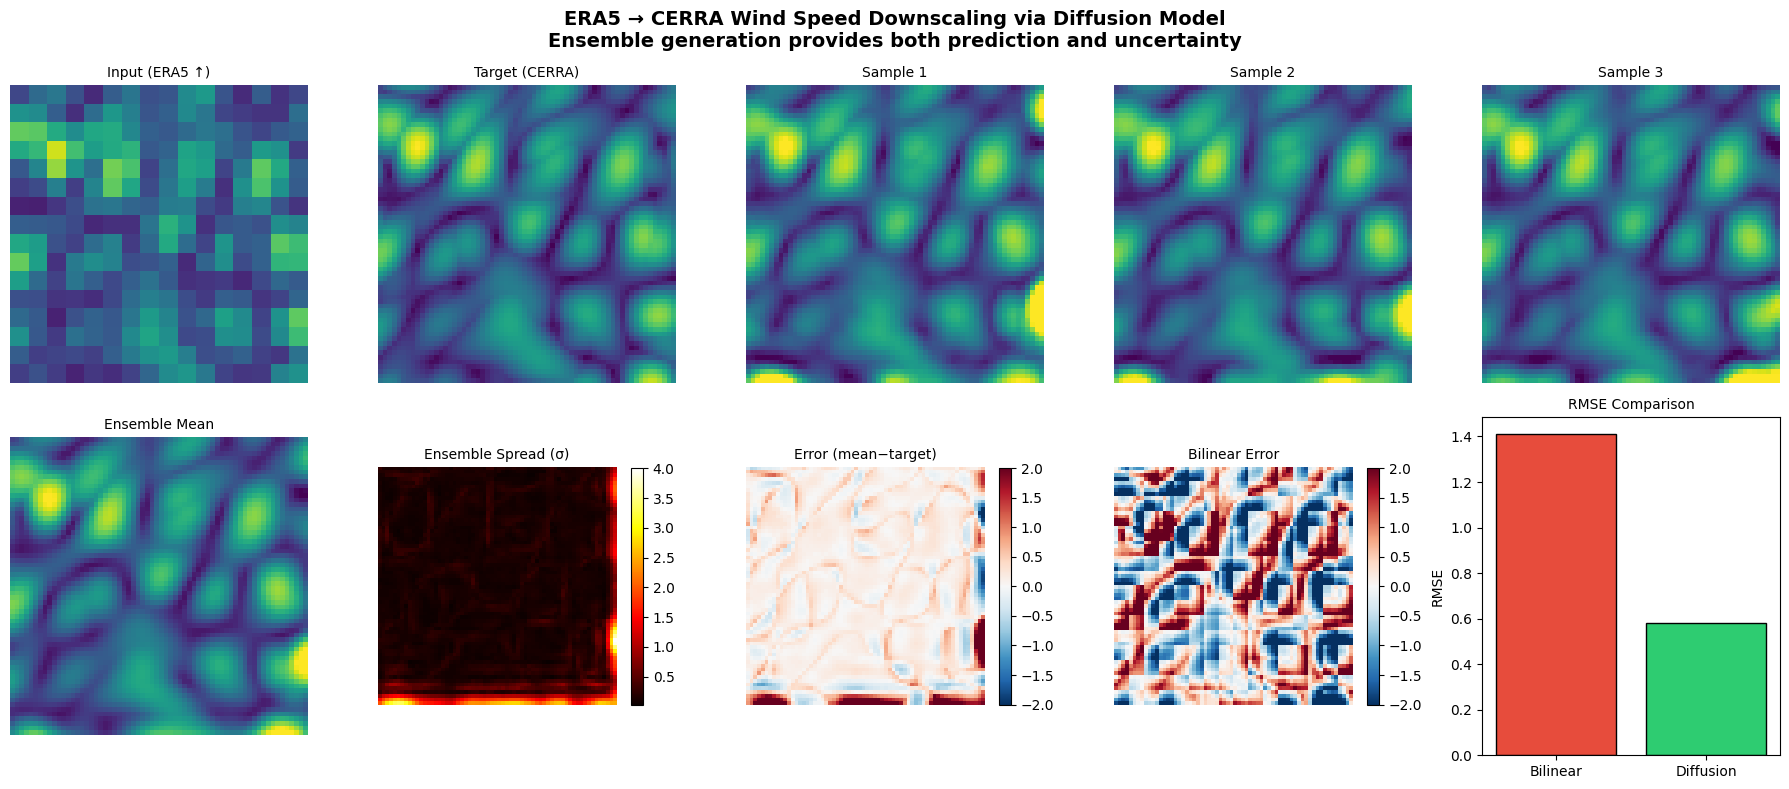

In [ ]:
# Visualize ensemble downscaling results
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

vmin, vmax = hr_true.min(), hr_true.max()

# Row 1: Input, target, and 3 ensemble members
axes[0,0].imshow(lr_up, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0,0].set_title('Input (ERA5 ↑)', fontsize=10); axes[0,0].axis('off')
axes[0,1].imshow(hr_true, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0,1].set_title('Target (CERRA)', fontsize=10); axes[0,1].axis('off')
for i in range(3):
    axes[0, i+2].imshow(ens_np[i, 0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, i+2].set_title(f'Sample {i+1}', fontsize=10); axes[0, i+2].axis('off')

# Row 2: Ensemble mean, std, and error maps
ens_mean = ens_np[:, 0].mean(axis=0)
ens_std = ens_np[:, 0].std(axis=0)
axes[1,0].imshow(ens_mean, cmap='viridis', vmin=vmin, vmax=vmax)
axes[1,0].set_title('Ensemble Mean', fontsize=10); axes[1,0].axis('off')
im_std = axes[1,1].imshow(ens_std, cmap='hot'); plt.colorbar(im_std, ax=axes[1,1], shrink=0.7)
axes[1,1].set_title('Ensemble Spread (σ)', fontsize=10); axes[1,1].axis('off')
err = ens_mean - hr_true
im_err = axes[1,2].imshow(err, cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im_err, ax=axes[1,2], shrink=0.7)
axes[1,2].set_title('Error (mean−target)', fontsize=10); axes[1,2].axis('off')
# Bilinear error
err_bl = lr_up - hr_true
im_bl = axes[1,3].imshow(err_bl, cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar(im_bl, ax=axes[1,3], shrink=0.7)
axes[1,3].set_title('Bilinear Error', fontsize=10); axes[1,3].axis('off')
# RMSE comparison
rmse_diff = np.sqrt(np.mean(err**2))
rmse_bl = np.sqrt(np.mean(err_bl**2))
axes[1,4].bar(['Bilinear', 'Diffusion'], [rmse_bl, rmse_diff],
              color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1,4].set_ylabel('RMSE'); axes[1,4].set_title('RMSE Comparison', fontsize=10)

fig.suptitle('ERA5 → CERRA Wind Speed Downscaling via Diffusion Model\n'
             'Ensemble generation provides both prediction and uncertainty',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Part 4: Exercises

### Exercise 1: DDIM Accelerated Sampling (⭐⭐)
DDPM requires T reverse steps, which is slow. Implement **DDIM** (Song et al., 2021) sampling that uses only 5–10 steps (matching the ERA5→CERRA paper's approach). Compare sample quality at 5, 10, 20, and 50 steps.


---
## References

### Core Repositories

1. **GenerativeNowcasting** — SHADECast: Solar irradiance nowcasting via latent diffusion. [github.com/EnergyWeatherAI/GenerativeNowcasting](https://github.com/EnergyWeatherAI/GenerativeNowcasting) | [arXiv:2312.11966](https://arxiv.org/abs/2312.11966)

2. **DiffESM** — Conditional emulation of ESMs for daily temp/precip. [github.com/JGCRI/diffesm](https://github.com/JGCRI/diffesm) | [arXiv:2409.11601](https://arxiv.org/abs/2409.11601)

3. **ERA5-to-CERRA-via-Diffusion-Models** — Wind speed downscaling. [github.com/fmerizzi/ERA5-to-CERRA-via-Diffusion-Models](https://github.com/fmerizzi/ERA5-to-CERRA-via-Diffusion-Models) | [arXiv:2401.15469](https://arxiv.org/abs/2401.15469)

4. **Awesome-Diffusion-Models-for-Weather-Forecasting** — Curated paper list. [github.com/hoonerg/Awesome-Diffusion-Models-for-Weather-Forecasting](https://github.com/hoonerg/Awesome-Diffusion-Models-for-Weather-Forecasting)

### Key Papers

5. **Ho, J., Jain, A., & Abbeel, P. (2020).** Denoising Diffusion Probabilistic Models. *NeurIPS 2020*. [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)

6. **Leinonen, J., et al. (2023).** Latent diffusion models for generative precipitation nowcasting with accurate uncertainty quantification. [arXiv:2304.12891](https://arxiv.org/abs/2304.12891)

7. **Price, I., et al. (2024).** GenCast: Diffusion-based ensemble forecasting for medium-range weather. *Science*.

8. **Gao, Z., et al. (2023).** PreDiff: Precipitation Nowcasting with Latent Diffusion Models. *NeurIPS 2023*.

9. **Song, J., Meng, C., & Ermon, S. (2021).** Denoising Diffusion Implicit Models (DDIM). *ICLR 2021*. [arXiv:2010.02502](https://arxiv.org/abs/2010.02502)

10. **Bassetti, S., et al. (2024).** Diffusion-Based Joint Temperature and Precipitation Emulation of Earth System Models. *ICLR 2024 Workshop*.